In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


df= pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])



In [5]:
df.dropna(inplace=True)
df.shape

(714, 3)

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
X= df.drop('Survived',axis=1)
y= df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [8]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

In [9]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=5,scoring='accuracy'))

np.float64(0.6134640007879444)

In [19]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
KBin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')

trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', KBin_fare, [1])
])

X_train_trans = trf.fit_transform(X_train)
X_test_trans = trf.transform(X_test)


trf.named_transformers_['first'].bin_edges_[0]
trf.named_transformers_['second'].bin_edges_[0]
clf.fit(X_train_trans,y_train)
y_pred = clf.predict(X_test_trans)
accuracy_score(y_test,y_pred)   



c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly t

0.6363636363636364

In [30]:
from scipy import stats
def distribution(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    KBin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', KBin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=5,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X['Age'],kde=True)
    plt.title('Age PDF')

    plt.subplot(122)
    stats.probplot(X['Age'],dist = "norm", plot = plt)
    plt.title('Age QQ plot')
    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X['Fare'],kde=True)
    plt.title('Fare PDF')

    plt.subplot(122)
    stats.probplot(X['Fare'],dist = "norm", plot = plt)
    plt.title('Fare QQ plot')
    plt.show()
    

c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6624642962671131


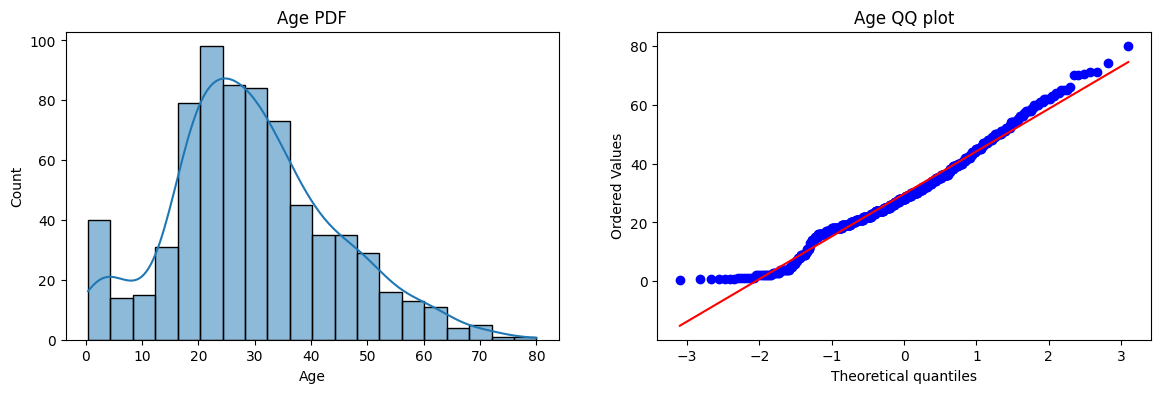

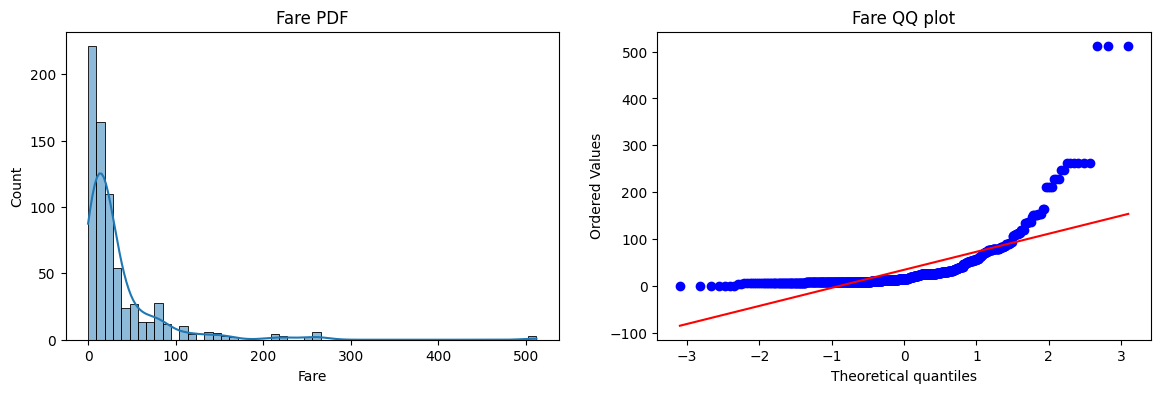

In [31]:
distribution(10,'quantile')

In [33]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Example dataset (Titanic-style: age, fare, survived)
data = pd.DataFrame({
    'age': [22, 38, 26, 35, 28, 40, 50, 18, 60, 30],
    'fare': [7.25, 71.83, 7.92, 53.1, 8.05, 27.9, 83.47, 13.0, 52.0, 21.0],
    'survived': [0, 1, 1, 1, 0, 0, 1, 0, 1, 0]
})

X = data[['age', 'fare']]
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define binning transformers
kbin_age = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

# Apply binning automatically via ColumnTransformer
trf = ColumnTransformer([
    ('age_binner', kbin_age, ['age']),
    ('fare_binner', kbin_fare, ['fare'])
])

# Build a pipeline: binning + classifier
pipe = Pipeline([
    ('binning', trf),
    ('clf', LogisticRegression())
])

# Fit the pipeline
pipe.fit(X_train, y_train)

# Predict on test data
y_pred = pipe.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

print("Age bin edges:", pipe.named_steps['binning'].named_transformers_['age_binner'].bin_edges_[0])
print("Fare bin edges:", pipe.named_steps['binning'].named_transformers_['fare_binner'].bin_edges_[0])
print("Transformed test data:\n", pipe.named_steps['binning'].transform(X_test))
print("Accuracy score:", acc)

Age bin edges: [18.  22.8 26.8 29.2 34.  50. ]
Fare bin edges: [ 7.25   7.946 10.03  17.8   46.68  83.47 ]
Transformed test data:
 [[4. 4.]
 [4. 4.]
 [4. 3.]]
Accuracy score: 0.6666666666666666


c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\conda_envs\eda\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
